In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load significant HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 384/384 [00:19<00:00, 19.56it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0023_RPIF9-10,0.078616,True,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Angular,AG,R,66.9825,-15.8252,2.2064
1,-1.0,D0023_RMSF6-7,0.095273,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,ACC,R,15.5138,35.3361,21.1440
2,-1.0,D0023_RPIF8-9,0.542296,True,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Angular,AG,R,63.9963,-16.0396,1.1741
3,-1.0,D0023_RPIF2-3,0.139837,False,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_Lat_Fis-post,Sylvian–SMG,R,41.6243,-11.5420,-1.6901
4,-1.0,D0023_RPIF4-5,0.255397,False,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Supramar,SMG–Sylvian,R,49.3894,-13.0340,-1.0607


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 171200
PIC electrode count: 49280
Unclassified electrode count: 116480
Unclassified label types: ['Left-Cerebral-White-Matter' 'Unknown' 'Right-Cerebral-White-Matter']


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0023_RPIF9-10,0.078616,True,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Angular,AG,R,66.9825,-15.8252,2.2064
1,-1.0,D0023_RMSF6-7,0.095273,False,D0023,Decision,LexicalDelay,delay,sound,Right-Cerebral-White-Matter,ACC,R,15.5138,35.3361,21.1440
2,-1.0,D0023_RPIF8-9,0.542296,True,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Angular,AG,R,63.9963,-16.0396,1.1741
3,-1.0,D0023_RPIF2-3,0.139837,False,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_Lat_Fis-post,Sylvian–SMG,R,41.6243,-11.5420,-1.6901
4,-1.0,D0023_RPIF4-5,0.255397,False,D0023,Decision,LexicalDelay,delay,sound,ctx_rh_G_pariet_inf-Supramar,SMG–Sylvian,R,49.3894,-13.0340,-1.0607


In [6]:
# fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
# cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
# translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
# HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

# Functional

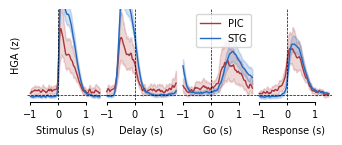

In [7]:
rois = ['PIC', 'STG']

colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    # & (HGAs.hemi=='L')
    & (HGAs.roi.isin(rois))
    & (HGAs.subject!='D0121')
]

phases = ['stimulus', 'delay', 'go' ,'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, 3*cm),)

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (ax, phase) in zip(axes, phases):
    
    legend = True if ax == axes[-2] else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1
    )
    
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
    if ax != axes[0]:
        # ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

# plt.savefig('../img/fig2/fig2_AIPI_temporal_LS_{}.svg'.format('_'.join(rois)), dpi=300, bbox_inches='tight')
plt.show()

## Heatmap

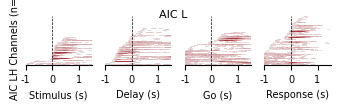

In [8]:
import xarray as xr

roi = 'AIC'
hemi = 'L'
cmap=reds
phases = ['stimulus', 'delay', 'go', 'response']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    # & (HGAs.hemi == hemi)
    & (HGAs.roi == roi)
    & (HGAs.subject != 'D0121')
]

agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data.loc[~agg_data['mask'], 'value'] = np.nan

max_channels = 0
phase_channel_map = {}
for phase in phases:
    phase_data = agg_data[agg_data.phase == phase]
    sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
    phase_channel_map[phase] = sorted_channels
    max_channels = max(max_channels, len(sorted_channels))

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, float(0.02*max_channels*cm)))

for ax, phase in zip(axes, phases):
    sorted_channels = phase_channel_map[phase]
    phase_data = agg_data[agg_data.phase == phase]
    
    if len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels)
        continue
    
    phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels) + 1)
    
    # Build meshgrid for pcolormesh
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=0, vmax=1.5, shading='auto', rasterized=True)
    
    sns.despine(ax=ax, offset=0, trim=False)
    ax.spines['left'].set_visible(False)
    # fixed ticks at -1, 0, 1
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['-1','0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels)
    
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
    else:
        ax.set_ylabel(f'', fontsize=7)

plt.suptitle(f'{roi} {hemi}', fontsize=8)
# plt.savefig(f'../img/fig2/heatmap_{roi}_{hemi}_channels.svg',dpi=300,bbox_inches='tight')
plt.show()

# Spatial Distribution

In [11]:
phase = 'stimulus'

spatial = subset[
    (subset.phase == phase)
    & (subset.time>0)
    & (subset.time<0.5)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0023_R2IF1-2,0.133529,35.7033,7.35276,-0.947400,AIC,ctx_rh_S_circular_insula_sup,stimulus,R,D0023,Repeat,LexicalDelay
1,D0027_LAI3-4,0.069447,-29.3719,31.56180,-8.525500,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,Repeat,LexicalDelay
2,D0044_LI7-8,0.371597,-34.2336,9.60212,-11.353870,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0044,Repeat,LexicalDelay
3,D0047_LI3-4,0.170820,-35.4561,22.98152,-23.336600,AIC,ctx_lh_G_insular_short,stimulus,L,D0047,Repeat,LexicalDelay
4,D0047_LI4-5,0.351007,-35.4520,23.14228,-19.320535,AIC,ctx_lh_G_insular_short,stimulus,L,D0047,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-07-08 13:30:22.450 ( 193.403s) [    7FCCF6A3E740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x23caefd0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

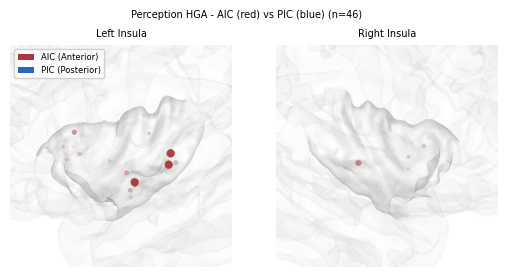

In [12]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',  
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)


for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 30

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig(f'../img/fig2/fig2_AIPI_spatial_{phase}.svg', dpi=300, bbox_inches='tight')

# Connectivity

In [8]:
tasks = ["LexicalDelay", "PhonemeSequence",'PictureNaming', 'SentenceRep']
ref = "bipolar"

all_ds = []
all_clusters = []

for task_name in tasks:
    results_root = f"../results/{task_name}({ref})"

    base = BIDSPath(
        root=results_root,
        datatype="xcorr",
        task=task_name,
        recording="highgamma",
        description='Repeat',
        suffix="perm",
        check=False,
    )

    nc_paths = base.copy().update(extension=".nc").match()
    csv_paths = base.copy().update(extension=".csv").match()

    print(f"[{task_name}] nc={len(nc_paths)} csv={len(csv_paths)}")

    # load nc
    for p in nc_paths:
        ds = xr.load_dataset(p)
        ds = ds.assign_attrs({
            **ds.attrs,
            "task": task_name,
            "phase": p.processing,
            "description": p.description,
            "file": str(p.fpath),
        })
        all_ds.append(ds)

    # load csv
    for p in csv_paths:
        df = pd.read_csv(p.fpath)
        df["task"] = task_name
        df["phase"] = p.processing
        df["description"] = p.description
        df["file"] = str(p.fpath)
        all_clusters.append(df)

ds_all = xr.concat(all_ds, dim="pair") if all_ds else None
clusters_df = pd.concat(all_clusters, ignore_index=True) if all_clusters else pd.DataFrame()

print("Total datasets loaded:", len(all_ds))
print("Total cluster tables loaded:", len(all_clusters))
print("Total cluster rows:", len(clusters_df))
clusters_df.head()

[LexicalDelay] nc=175 csv=175
[PhonemeSequence] nc=177 csv=177
[PictureNaming] nc=0 csv=0
[SentenceRep] nc=121 csv=121
Total datasets loaded: 473
Total cluster tables loaded: 473
Total cluster rows: 13919


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file
0,1,D0023_RPIF2-3,D0023_RPIF4-5,-0.023438,0.023438,0.116404,0.038961,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,26,D0023_R2IF4-5,D0023_R1MF12-13,0.257812,0.328125,0.101834,0.048951,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,28,D0023_R2IF4-5,D0023_R2MF1-2,-0.039062,0.031250,0.094911,0.036963,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,44,D0023_RPSF1-2,D0023_RPIF8-9,-0.046875,0.062500,0.211966,0.013986,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,59,D0023_RPSF1-2,D0023_RPMF11-12,-0.125000,-0.062500,0.123267,0.044955,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


In [9]:
# --- simplest global merge for multi-task + multi-phase ---
# no xcorr_task / xcorr_phase filter

# 1) global channel metadata
channel_meta = (
    HGAs[["channel", "roi", "hemi"]]
    .dropna()
    .groupby(["channel", "roi", "hemi"], as_index=False)
    .size()
    .sort_values(["channel", "size"], ascending=[True, False])
    .drop_duplicates("channel")
    .drop(columns="size")
)

# 2) merge to significant clusters (all tasks/phases already in clusters_df)
sig_roi_df = (
    clusters_df.loc[clusters_df["significant"] == True].copy()
    .merge(
        channel_meta.rename(columns={
            "channel": "source_channel",
            "roi": "source_roi",
            "hemi": "source_hemi"
        }),
        on="source_channel",
        how="left",
    )
    .merge(
        channel_meta.rename(columns={
            "channel": "target_channel",
            "roi": "target_roi",
            "hemi": "target_hemi"
        }),
        on="target_channel",
        how="left",
    )
)

# 3) quick QC
print("sig rows:", len(sig_roi_df))
print("missing source_roi:", sig_roi_df["source_roi"].isna().sum())
print("missing target_roi:", sig_roi_df["target_roi"].isna().sum())
print("missing source_hemi:", sig_roi_df["source_hemi"].isna().sum())
print("missing target_hemi:", sig_roi_df["target_hemi"].isna().sum())

sig_roi_df.head(10)

sig rows: 13919
missing source_roi: 25
missing target_roi: 33
missing source_hemi: 25
missing target_hemi: 33


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file,source_roi,source_hemi,target_roi,target_hemi
0,1,D0023_RPIF2-3,D0023_RPIF4-5,-0.023438,0.023438,0.116404,0.038961,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Sylvian,R,Intersection,R
1,26,D0023_R2IF4-5,D0023_R1MF12-13,0.257812,0.328125,0.101834,0.048951,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,Intersection,R
2,28,D0023_R2IF4-5,D0023_R2MF1-2,-0.039062,0.031250,0.094911,0.036963,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,Intersection,R,dACC,R
3,44,D0023_RPSF1-2,D0023_RPIF8-9,-0.046875,0.062500,0.211966,0.013986,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,CGs,R,AG,R
4,59,D0023_RPSF1-2,D0023_RPMF11-12,-0.125000,-0.062500,0.123267,0.044955,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,CGs,R,Intersection,R
5,83,D0023_R2MF10-11,D0023_R1MF12-13,-0.148438,0.078125,0.845900,0.000999,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,SMC,R,Intersection,R
6,84,D0023_R2MF10-11,D0023_R1MF13-14,-0.101562,0.070312,0.548838,0.000999,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,SMC,R,Intersection,R
7,86,D0023_R2MF10-11,D0023_RPIF3-4,-0.375000,-0.187500,0.423833,0.001998,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,SMC,R,Intersection,R
8,89,D0023_R2MF10-11,D0023_R1MF11-12,-0.101562,0.101562,0.742494,0.000999,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,SMC,R,IFGs,R
9,93,D0023_R2MF10-11,D0023_RPIF2-3,-0.335938,-0.218750,0.243024,0.014985,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...,SMC,R,Sylvian,R


In [14]:
from pathlib import Path

# ===== config =====
min_peak_val = 0.05      # 强度阈值
max_abs_lag_s = 0.5       # lag范围阈值（秒）

# Cache datasets by file to avoid repeated I/O
ds_cache = {}

def get_ds(nc_file):
    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)
    return ds_cache[nc_file]

# Work on significant clusters only
sig = sig_roi_df.copy()

# robust csv -> nc path
sig["nc_file"] = sig["file"].apply(lambda x: str(Path(x).with_suffix(".nc")))

peak_rows = []
n_skip_pair_idx = 0
n_skip_empty_window = 0
n_skip_all_nan = 0

for _, row in sig.iterrows():
    nc_file = row["nc_file"]
    pair_idx = int(row["pair_idx"])
    lag_start = float(row["lag_start_s"])
    lag_end = float(row["lag_end_s"])

    ds = get_ds(nc_file)

    # Guard against out-of-range pair index
    if pair_idx < 0 or pair_idx >= ds.sizes["pair"]:
        n_skip_pair_idx += 1
        continue

    obs = ds["observed_curve"].isel(pair=pair_idx).values
    nul = ds["null_mean"].isel(pair=pair_idx).values
    lag = ds["lag"].values

    # cluster window
    mask = (lag >= lag_start) & (lag <= lag_end)
    if not mask.any():
        n_skip_empty_window += 1
        continue

    obs_in_cluster = obs[mask]
    lag_in_cluster = lag[mask]

    if not np.isfinite(obs_in_cluster).any():
        n_skip_all_nan += 1
        continue

    # peak within cluster
    peak_idx_local = np.nanargmax(obs_in_cluster)
    peak_lag = float(lag_in_cluster[peak_idx_local])
    peak_val = float(obs_in_cluster[peak_idx_local])

    # null mean at nearest lag
    peak_idx_global = int(np.argmin(np.abs(lag - peak_lag)))
    null_at_peak = float(nul[peak_idx_global])
    peak_excess = peak_val - null_at_peak

    # cluster interval (normalized: left <= right)
    cluster_left = min(lag_start, lag_end)
    cluster_right = max(lag_start, lag_end)
    cluster_mid = 0.5 * (lag_start + lag_end)

    # flags
    is_near_zero = abs(peak_lag) < 0.05
    in_range = abs(peak_lag) <= max_abs_lag_s

    if peak_lag > 0.01:
        direction = "source_leads"
    elif peak_lag < -0.01:
        direction = "target_leads"
    else:
        direction = "sync"

    peak_rows.append({
        "pair_idx": pair_idx,
        "source_channel": row["source_channel"],
        "target_channel": row["target_channel"],
        "source_roi": row.get("source_roi"),
        "target_roi": row.get("target_roi"),
        "source_hemi": row.get("source_hemi"),
        "target_hemi": row.get("target_hemi"),
        "lag_start_s": lag_start,
        "lag_end_s": lag_end,
        "cluster_left_s": cluster_left,
        "cluster_right_s": cluster_right,
        "cluster_mid_s": cluster_mid,
        "cluster_width_s": lag_end - lag_start,
        "cluster_mass": row["mass"],
        "p_value": row["p_value"],
        "peak_lag_s": peak_lag,
        "peak_val": peak_val,
        "null_at_peak": null_at_peak,
        "peak_excess": peak_excess,
        "is_near_zero": is_near_zero,
        "in_range": in_range,
        "direction": direction,
        "task": row.get("task"),
        "phase": row.get("phase"),
        "description": row.get("description"),
        "file": row["file"],
    })

peaks_df_raw = pd.DataFrame(peak_rows)

# ===== post-filter for downstream analysis =====
peaks_df = peaks_df_raw[
    (peaks_df_raw["peak_val"] >= min_peak_val) &
    (peaks_df_raw["peak_lag_s"].abs() <= max_abs_lag_s)
].copy()

print(f"Total significant clusters (raw): {len(peaks_df_raw)}")
print(f"After filter peak_val>={min_peak_val} & |lag|<={max_abs_lag_s}s: {len(peaks_df)}")
print(f"Removed by filter: {len(peaks_df_raw) - len(peaks_df)}")
print(f"Near-zero peaks (|lag|<0.05s): {peaks_df['is_near_zero'].sum()}")
print(f"Out-of-range peaks: {(~peaks_df['in_range']).sum()}")
print(f"Skipped (pair_idx out of range): {n_skip_pair_idx}")
print(f"Skipped (empty lag window): {n_skip_empty_window}")
print(f"Skipped (all-NaN in cluster window): {n_skip_all_nan}")

peaks_df.head()

Total significant clusters (raw): 13919
After filter peak_val>=0.05 & |lag|<=0.5s: 13150
Removed by filter: 769
Near-zero peaks (|lag|<0.05s): 8092
Out-of-range peaks: 0
Skipped (pair_idx out of range): 0
Skipped (empty lag window): 0
Skipped (all-NaN in cluster window): 0


,pair_idx,source_channel,target_channel,source_roi,target_roi,source_hemi,target_hemi,lag_start_s,lag_end_s,cluster_left_s,...,peak_val,null_at_peak,peak_excess,is_near_zero,in_range,direction,task,phase,description,file
0,1,D0023_RPIF2-3,D0023_RPIF4-5,Sylvian,Intersection,R,R,-0.023438,0.023438,-0.023438,...,0.084855,0.064200,0.020654,True,True,sync,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,26,D0023_R2IF4-5,D0023_R1MF12-13,Intersection,Intersection,R,R,0.257812,0.328125,0.257812,...,0.050224,0.037592,0.012632,False,True,source_leads,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,28,D0023_R2IF4-5,D0023_R2MF1-2,Intersection,dACC,R,R,-0.039062,0.031250,-0.039062,...,0.059117,0.048105,0.011012,True,True,target_leads,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,44,D0023_RPSF1-2,D0023_RPIF8-9,CGs,AG,R,R,-0.046875,0.062500,-0.046875,...,0.084576,0.067359,0.017216,True,True,target_leads,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,59,D0023_RPSF1-2,D0023_RPMF11-12,CGs,Intersection,R,R,-0.125000,-0.062500,-0.125000,...,0.070740,0.053886,0.016854,False,True,target_leads,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


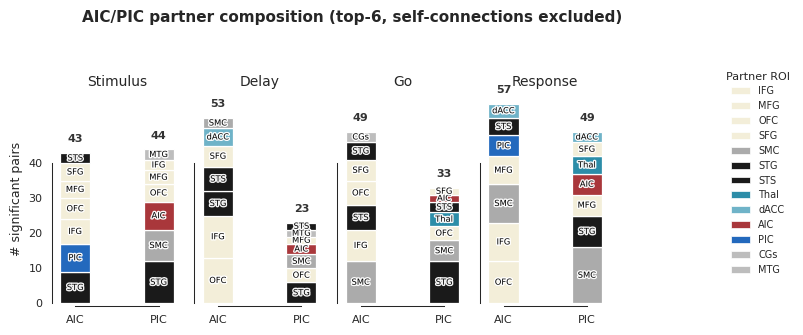

In [15]:
import matplotlib.patheffects as pe

# ===================== config =====================
# phases = ["stimulus", "delay", "go", "response"]

phases = ["stimulus", "delay", "go", "response"]
focus_rois = ["AIC", "PIC"]
top_k = 7

# label controls
label_inside_min = 2      # larger threshold: only big segments get inside text
max_outside_labels = 0    # disable outside callouts (cleaner)

exclude_rois = {"Intersection", "LinG", "OccS", "CollatAnt", "Central"}
roi_map = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

# ===================== prepare =====================
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

max_abs_lag_ms = 500
df = df[df["peak_lag_s"].abs() <= max_abs_lag_ms / 1000].copy()

df = df.dropna(subset=["source_roi", "target_roi", "source_channel", "target_channel", "phase_norm"])
df = df[
    (~df["source_roi"].isin(exclude_rois)) &
    (~df["target_roi"].isin(exclude_rois)) &
    (df["phase_norm"].isin(phases))
].copy()

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

rows = []
for focus in focus_rois:
    tmp = df[(df["source_roi"] == focus) | (df["target_roi"] == focus)].copy()
    tmp = tmp[~((tmp["source_roi"] == focus) & (tmp["target_roi"] == focus))].copy()
    if tmp.empty:
        continue
    tmp["focus_roi"] = focus
    tmp["partner_roi"] = np.where(tmp["source_roi"] == focus, tmp["target_roi"], tmp["source_roi"])
    rows.append(tmp[["phase_norm", "focus_roi", "partner_roi", "pair_key"]])

if not rows:
    raise RuntimeError("No rows left after filtering.")

long_df = pd.concat(rows, ignore_index=True)

agg = (
    long_df.groupby(["phase_norm", "focus_roi", "partner_roi"], as_index=False)
           .agg(n_pairs=("pair_key", "nunique"))
)

top_chunks = []
for ph in phases:
    for focus in focus_rois:
        sub = agg[(agg["phase_norm"] == ph) & (agg["focus_roi"] == focus)].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("n_pairs", ascending=False).head(top_k)
        top_chunks.append(sub)

if not top_chunks:
    raise RuntimeError("No top-k partners found.")

top_df = pd.concat(top_chunks, ignore_index=True)

# ===================== region-family color mapping =====================
partners = sorted(top_df["partner_roi"].unique())

partner2color = {
    "IFG": "#f3eed9",
    "MFG": "#f3eed9",
    "OFC": "#f3eed9",
    "SFG": "#f3eed9",
    "SMC": "#ababab",
    "STG": "#1A1A1A",
    "STS": "#1A1A1A",
    "Thal": "#2C8DA8",
    "dACC": "#6FB3C8",
    "AIC": red,
    "PIC": blue,
}

fallback_color = "#bdbdbd"
for p in partners:
    if p not in partner2color:
        partner2color[p] = fallback_color

# ===================== plot =====================
sns.set_theme(style="white")
fig, axes = plt.subplots(1, len(phases), figsize=(1.8 * len(phases), 3.4), sharey=True)
if len(phases) == 1:
    axes = [axes]

for ax, ph in zip(axes, phases):
    x_pos = np.array([0, 1])
    bar_width = 0.36
    totals = []

    for i, focus in enumerate(focus_rois):
        sub = top_df[(top_df["phase_norm"] == ph) & (top_df["focus_roi"] == focus)].copy()
        bottom = 0
        if sub.empty:
            totals.append(0)
            continue

        for _, r in sub.sort_values("n_pairs", ascending=False).iterrows():
            v = r["n_pairs"]
            p = r["partner_roi"]

            ax.bar(
                x_pos[i], v, width=bar_width, bottom=bottom,
                color=partner2color[p], edgecolor="white", linewidth=0.9
            )

            y_center = bottom + v / 2
            if v >= label_inside_min:
                t = ax.text(
                    x_pos[i], y_center, p,
                    ha="center", va="center", fontsize=6, fontweight="medium", color="black"
                )
                t.set_path_effects([pe.withStroke(linewidth=2, foreground="white", alpha=0.95)])

            bottom += v

        totals.append(bottom)

    # title per panel
    ax.set_title(ph.capitalize(), fontsize=10, fontweight="medium", pad=6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(focus_rois, fontsize=8)
    ax.tick_params(labelsize=8, width=0.8, length=3, which="both")

    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
    sns.despine(ax=ax, offset=2, trim=True)

    # total labels (moved higher to avoid overlap)
    for i, t in enumerate(totals):
        ax.text(x_pos[i], t + 2.5, f"{int(t)}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#333")

axes[0].set_ylabel("# significant pairs", fontsize=9)
for ax in axes[1:]:
    ax.set_ylabel("")

# legend: only actually appearing partners, right side
legend_order = ["IFG", "MFG", "OFC", "SFG", "SMC", "STG", "STS", "Thal", "dACC", "AIC", "PIC"]
legend_partners = [p for p in legend_order if p in partners] + [p for p in partners if p not in legend_order]

handles = [plt.Rectangle((0, 0), 1, 1, color=partner2color[p], ec="white", lw=0.5) for p in legend_partners]
fig.legend(
    handles, legend_partners, title="Partner ROI",
    loc="center right", bbox_to_anchor=(1.12, 0.5),
    ncol=1, frameon=False, fontsize=7, title_fontsize=8
)

fig.suptitle("AIC/PIC partner composition (top-6, self-connections excluded)", fontsize=11, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
# plt.savefig("../img/misc/xcorr_partner_composition.svg", dpi=300, bbox_inches="tight")
plt.show()

Delay AIC-involving pairs: 167
Unique AIC electrodes: 48
Unique partner electrodes: 117
AIC coords: (48, 3), Partner coords: (117, 3)
Partner density clipped range (p10, p80): [0.387, 1.992]


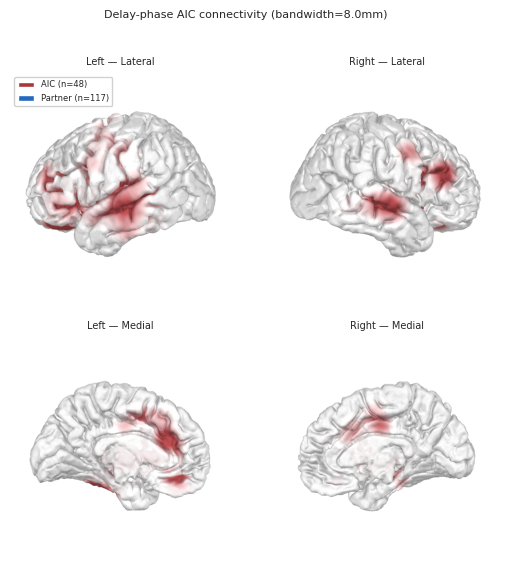

In [21]:
# ============================================================
# Delay-phase AIC connectivity on cvs_avg35_inMNI152 (PIAL)
# - AIC electrodes (red) vs partner electrodes (blue)
# - Gaussian KDE density layer for partners
# ============================================================
from scipy.spatial.distance import cdist
from scipy.spatial import cKDTree
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pyvista as pv
from mne.viz import Brain

# ---------- 0. load pial surfaces ----------
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# ---------- 1. select Delay-phase AIC pairs ----------
delay_df = sig_roi_df[
    (sig_roi_df["phase"] == "Delay")
    & (sig_roi_df["source_roi"].notna())
    & (sig_roi_df["target_roi"].notna())
].copy()

roi = 'AIC'
src_is_roi = delay_df["source_roi"] == roi
tgt_is_roi = delay_df["target_roi"] == roi
# XOR: exactly one side is roi (roi-roi pairs excluded)
delay_df = delay_df[src_is_roi ^ tgt_is_roi].copy()

# AIC channel and partner channel per row
delay_df["aic_channel"] = np.where(
    delay_df["source_roi"] == roi,
    delay_df["source_channel"],
    delay_df["target_channel"],
)
delay_df["partner_channel"] = np.where(
    delay_df["source_roi"] == roi,
    delay_df["target_channel"],
    delay_df["source_channel"],
)

aic_channels = set(delay_df["aic_channel"]) - set(exclude_chn)
partner_channels = set(delay_df["partner_channel"]) - set(exclude_chn)

print(f"Delay {roi}-involving pairs: {len(delay_df)}")
print(f"Unique {roi} electrodes: {len(aic_channels)}")
print(f"Unique partner electrodes: {len(partner_channels)}")

# ---------- 2. pull MNI-corrected coords from HGAs ----------
coord_lookup = (
    HGAs[["channel", "x", "y", "z"]]
    .dropna()
    .groupby("channel", as_index=False)
    .first()
    .set_index("channel")
)

aic_coords = coord_lookup.loc[
    [c for c in aic_channels if c in coord_lookup.index]
][["x", "y", "z"]].values
partner_coords = coord_lookup.loc[
    [c for c in partner_channels if c in coord_lookup.index]
][["x", "y", "z"]].values

print(f"AIC coords: {aic_coords.shape}, Partner coords: {partner_coords.shape}")

# ---------- 3. density helper (partner electrodes, uniform weight=1) ----------
bandwidth = 8.0
max_distance = 15.0
density_opacity = 0.9

def compute_density(surface_coords, electrode_coords, bandwidth, max_distance):
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
    distances = cdist(surface_coords, electrode_coords)
    mask = distances.min(axis=1) < max_distance
    kernel = np.exp(-distances**2 / (2 * bandwidth**2))
    density = kernel.sum(axis=1)  # weight = 1 per electrode
    density[~mask] = 0
    return density, mask

# ---------- 4. electrode overlay helper ----------
def add_electrodes(brain, coords, tree, surf_coords, color, size=14, opacity=1.0):
    if len(coords) == 0:
        return
    _, idx = tree.query(coords)
    coords_proj = surf_coords[idx]
    cloud = pv.PolyData(coords_proj)
    brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=size,
        color=color,
        lighting=False,
        smooth_shading=False,
        opacity=opacity,
    )

# ---------- 5. compute densities on both pial surfaces ----------
mask_aic_lh = aic_coords[:, 0] < 0 if len(aic_coords) else np.array([], dtype=bool)
mask_aic_rh = aic_coords[:, 0] > 0 if len(aic_coords) else np.array([], dtype=bool)
mask_par_lh = partner_coords[:, 0] < 0 if len(partner_coords) else np.array([], dtype=bool)
mask_par_rh = partner_coords[:, 0] > 0 if len(partner_coords) else np.array([], dtype=bool)

lh_density, lh_dmask = compute_density(
    lh_pial_coords, partner_coords[mask_par_lh], bandwidth, max_distance
)
rh_density, rh_dmask = compute_density(
    rh_pial_coords, partner_coords[mask_par_rh], bandwidth, max_distance
)

all_valid = np.concatenate([
    lh_density[lh_dmask & (lh_density > 0)],
    rh_density[rh_dmask & (rh_density > 0)],
])
if len(all_valid):
    vmin_d = float(np.percentile(all_valid, 10))
    vmax_d = float(np.percentile(all_valid, 80))
else:
    vmin_d, vmax_d = 0.0, 1.0
print(f"Partner density clipped range (p10, p80): [{vmin_d:.3f}, {vmax_d:.3f}]")

# ---------- 6. bold blue colormap ----------
n_colors = 256
base_blue = np.array(mcolors.to_rgb(red))
start_mix = 0  # 0 = start from white, 1 = start from full blue
colors_list = [[1, 1, 1, 0]]  # index 0: fully transparent
for i in range(1, n_colors):
    t = start_mix + (1 - start_mix) * (i / (n_colors - 1))
    rgb = (1 - t) * np.array([1, 1, 1]) + t * base_blue
    colors_list.append(list(rgb) + [density_opacity])
density_cmap = ListedColormap(colors_list)

# ---------- 7. render helper: one Brain per (hemi, view) ----------
def render_brain(hemi, view, density, dmask, surf_coords, tree, aic_mask_h, par_mask_h):
    brain = Brain(
        "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial", hemi=hemi,
        background="white", show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(800, 800),
    )

    # Layer 1: density
    data = np.zeros(len(surf_coords))
    has_data = dmask & (density > 0)
    if has_data.any():
        norm = np.clip((density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1)
        data[has_data] = 1 + norm * (n_colors - 2)
    brain.add_data(
        data, hemi=hemi, colormap=density_cmap,
        alpha=1.0, colorbar=False, fmin=0, fmax=n_colors - 1,
    )

    # Layer 2: electrodes (partner first, AIC on top)
    # if par_mask_h.any():
    #     add_electrodes(brain, partner_coords[par_mask_h], tree, surf_coords,
    #                    color=blue, size=10, opacity=0.9)
    if aic_mask_h.any():
        add_electrodes(brain, aic_coords[aic_mask_h], tree, surf_coords,
                       color=red, size=14, opacity=1.0)

    brain.show_view(view=view, distance=400)
    return brain

# ---------- 8. render 4 panels: lateral + medial for each hemi ----------
panels = [
    ("lh", "lateral",  lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_aic_lh, mask_par_lh, "Left — Lateral"),
    ("rh", "lateral",  rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_aic_rh, mask_par_rh, "Right — Lateral"),
    ("lh", "medial",   lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_aic_lh, mask_par_lh, "Left — Medial"),
    ("rh", "medial",   rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_aic_rh, mask_par_rh, "Right — Medial"),
]

screenshots = []
brains = []
for hemi, view, density, dmask, surf_coords, tree, aic_mask_h, par_mask_h, title in panels:
    b = render_brain(hemi, view, density, dmask, surf_coords, tree, aic_mask_h, par_mask_h)
    screenshots.append((b.screenshot(mode="rgb"), title))
    brains.append(b)

# ---------- 9. assemble 2×2 matplotlib figure ----------
fig, axes = plt.subplots(2, 2, figsize=(16 * cm, 16 * cm))

for ax, (img, title) in zip(axes.flat, screenshots):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label=f"AIC (n={len(aic_channels)})"),
    Patch(facecolor=blue, label=f"Partner (n={len(partner_channels)})"),
]
axes[0, 0].legend(handles=legend_elements, loc="upper left",
                  fontsize=fontsize - 1, framealpha=0.9)

plt.suptitle(f"Delay-phase AIC connectivity (bandwidth={bandwidth}mm)",
             fontsize=fontsize + 1)

for b in brains:
    b.close()

plt.savefig("../img/fig2/fig2_delay_AIC_connectivity_brain.svg",
            dpi=300, bbox_inches="tight")
plt.show()

Filtered to |lag| <= 500 ms, remaining rows: 88
Partners: ['STG', 'IFG', 'STS', 'OFC', 'PCC']
Subjects: ['D0027', 'D0053', 'D0064', 'D0068', 'D0075', 'D0079', 'D0080', 'D0088', 'D0092', 'D0095', 'D0096', 'D0103', 'D0127', 'D0129']
Total pairs: 37


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2186830/515245269.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))


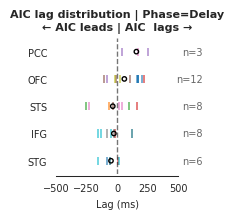

In [27]:
# ===================== config =====================
phase_keep = "delay"
focus_roi = "AIC"
top_k = 5

exclude_rois = {"Intersection", "LinG", "OccS", "CollatAnt", "Central"}
roi_map = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

# ===================== prepare =====================
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(roi_map)
df["target_roi"] = df["target_roi"].replace(roi_map)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df[
    (~df["source_roi"].isin(exclude_rois)) &
    (~df["target_roi"].isin(exclude_rois)) &
    (df["phase_norm"] == phase_keep)
].copy()

mask = (df["source_roi"] == focus_roi) | (df["target_roi"] == focus_roi)
df = df[mask].copy()
df = df[~((df["source_roi"] == focus_roi) & (df["target_roi"] == focus_roi))].copy()

df["partner_roi"] = np.where(df["source_roi"] == focus_roi, df["target_roi"], df["source_roi"])
df["lag_focus_leads"] = np.where(
    df["source_roi"] == focus_roi,
    df["peak_lag_s"],
    -df["peak_lag_s"]
)
max_abs_lag_ms = 500
df = df[df["lag_focus_leads"].abs() <= max_abs_lag_ms / 1000].copy()

print(f"Filtered to |lag| <= {max_abs_lag_ms} ms, remaining rows: {len(df)}")

# extract subject
df["subject"] = df["source_channel"].str.extract(r"^(D\d+)_")[0]

# undirected pair key
ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

# aggregate by pair (mean across tasks/descriptions), keep subject
agg = (
    df.groupby(["partner_roi", "pair_key", "subject"], as_index=False)
      .agg(lag_focus_leads=("lag_focus_leads", "mean"))
)

# 去掉 |lag| < 10 ms 的点（接近 0 的点）
min_lag_ms = 5  # 可调整阈值
agg = agg[agg["lag_focus_leads"].abs() >= min_lag_ms / 1000].copy()

# select top-k partners by count
partner_counts = agg.groupby("partner_roi").size().sort_values(ascending=False)
top_partners = partner_counts.head(top_k).index.tolist()
agg = agg[agg["partner_roi"].isin(top_partners)].copy()

# order partners by median lag
partner_order = (
    agg.groupby("partner_roi")["lag_focus_leads"]
       .median()
       .sort_values()
       .index.tolist()
)

# ===================== strip plot (no KDE) =====================
fig, ax = plt.subplots(figsize=(4*cm, (0.7 * len(partner_order) + 1) * cm))

# subject color mapping
subjects = sorted(agg["subject"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))
sub_to_color = {s: cmap(i) for i, s in enumerate(subjects)}

# y positions for each partner ROI
partner_to_y = {p: i for i, p in enumerate(partner_order)}


# 替换原来的 scatter 循环
for _, row in agg.iterrows():
    partner = row["partner_roi"]
    lag_ms = row["lag_focus_leads"] * 1000
    subj = row["subject"]
    y = partner_to_y[partner]
    
    ax.vlines(
        lag_ms, y - 0.15, y + 0.15,
        colors=sub_to_color[subj], linewidths=1.2, alpha=0.7
    )
    
# mean marker (one circle per partner ROI)
# subject-balanced center: each subject contributes equally
sub_center = (
    agg.groupby(["partner_roi", "subject"], as_index=False)
       .agg(sub_lag=("lag_focus_leads", "median"))   # subject内先用median更稳
)

center_df = (
    sub_center.groupby("partner_roi", as_index=False)
              .agg(center_lag=("sub_lag", "mean"))   # 再跨subject平均
)

# draw center marker
for _, r in center_df.iterrows():
    partner = r["partner_roi"]
    if partner not in partner_to_y:
        continue
    y = partner_to_y[partner]
    center_ms = r["center_lag"] * 1000
    
    ax.scatter(
        center_ms, y,
        s=10, marker="o",
        facecolor="None", edgecolor="black", linewidth=1,
        zorder=6
    )

# zero line
ax.axvline(0, color="k", ls="--", lw=1, alpha=0.6)

# formatting
ax.set_yticks(range(len(partner_order)))
ax.set_yticklabels(partner_order, fontsize=7)
ax.set_xlabel("Lag (ms)", fontsize=7)
ax.set_xlim(-500, 500)
ax.set_ylim(-0.5, len(partner_order) - 0.5)


ax.tick_params(labelsize=7, width=0.75, length=2, which="both")
for spine in ax.spines.values():
    spine.set_linewidth(0.75)
sns.despine(ax=ax, offset=1, trim=True)

# n count annotations
for partner in partner_order:
    n = len(agg[agg["partner_roi"] == partner])
    y = partner_to_y[partner]
    ax.text(700, y, f"n={n}", ha="right", va="center", fontsize=7, color="#666")

# subject legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sub_to_color[s], 
                       markersize=8, label=s) for s in subjects]
# ax.legend(handles=handles, title="Subject", loc="upper left", bbox_to_anchor=(1.02, 1), 
#           fontsize=8, title_fontsize=9, frameon=False)

ax.set_title(
    f"{focus_roi} lag distribution | Phase={phase_keep.capitalize()}\n"
    f"← {focus_roi} leads | {focus_roi}  lags →",
    fontsize=8, fontweight="bold"
)

sns.despine(ax=ax, left=True)
ax.tick_params(left=False)

print(f"Partners: {partner_order}")
print(f"Subjects: {subjects}")
print(f"Total pairs: {len(agg)}")

# fig.savefig(f"../img/misc/xcorr_lag_strip_{focus_roi}_{phase_keep}.svg", dpi=300, bbox_inches="tight")

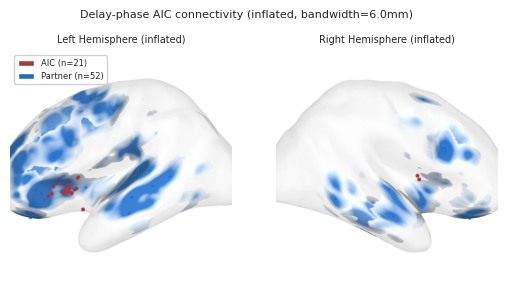

In [45]:
# ============================================================
# Delay-phase AIC connectivity on cvs_avg35_inMNI152 (INFLATED)
# - same data as the pial cell above, rendered on inflated surface
# - pial geometry used for electrode->vertex mapping & density
# - cortex background matches pial cell (light gray, low alpha)
# ============================================================
# Load inflated surface (pial already loaded in previous cell)
lh_infl_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.inflated")
rh_infl_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.inflated")

# Electrode overlay helper: nearest pial vertex -> render at inflated position
def add_electrodes_inflated(brain, coords, pial_tree, infl_coords,
                            color, size=14, opacity=1.0):
    if len(coords) == 0:
        return
    _, idx = pial_tree.query(coords)
    coords_on_infl = infl_coords[idx]
    cloud = pv.PolyData(coords_on_infl)
    brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=size,
        color=color,
        lighting=False,
        smooth_shading=False,
        opacity=opacity,
    )

# Render both hemispheres on inflated surface, reusing variables from pial cell
brains_infl = []
for hemi, density, dmask, infl_coords, tree, aic_mask_h, par_mask_h in [
    ("lh", lh_density, lh_dmask, lh_infl_coords, lh_tree, mask_aic_lh, mask_par_lh),
    ("rh", rh_density, rh_dmask, rh_infl_coords, rh_tree, mask_aic_rh, mask_par_rh),
]:
    brain = Brain(
        "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="inflated", hemi=hemi,
        background="white", show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(800, 800),
    )

    # Layer 1: density (same density arrays computed on pial, indexed by vertex)
    data = np.zeros(len(infl_coords))
    has_data = dmask & (density > 0)
    if has_data.any():
        norm = np.clip((density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1)
        data[has_data] = 1 + norm * (n_colors - 2)
    brain.add_data(
        data, hemi=hemi, colormap=density_cmap,
        alpha=1.0, colorbar=False, fmin=0, fmax=n_colors - 1,
    )

    # Layer 2: electrodes mapped onto inflated surface
    if par_mask_h.any():
        add_electrodes_inflated(brain, partner_coords[par_mask_h], tree, infl_coords,
                                color=blue, size=10, opacity=0.9)
    if aic_mask_h.any():
        add_electrodes_inflated(brain, aic_coords[aic_mask_h], tree, infl_coords,
                                color=red, size=14, opacity=1.0)

    brain.show_view(view="lateral", distance=400)
    brains_infl.append(brain)

# Assemble matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
axes[0].imshow(brains_infl[0].screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Hemisphere (inflated)", fontsize=fontsize)
axes[1].imshow(brains_infl[1].screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Hemisphere (inflated)", fontsize=fontsize)

legend_elements = [
    Patch(facecolor=red, label=f"AIC (n={len(aic_channels)})"),
    Patch(facecolor=blue, label=f"Partner (n={len(partner_channels)})"),
]
axes[0].legend(handles=legend_elements, loc="upper left",
               fontsize=fontsize - 1, framealpha=0.9)

plt.suptitle(f"Delay-phase AIC connectivity (inflated, bandwidth={bandwidth}mm)",
             fontsize=fontsize + 1)

for b in brains_infl:
    b.close()

# plt.savefig("../img/fig2/fig2_delay_AIC_connectivity_inflated.svg",
#             dpi=300, bbox_inches="tight")
plt.show()


# Unsupervised Clustering

### Load zscore

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 1711/1711 [00:46<00:00, 36.61it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,0.021346,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,0.055625,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,0.080085,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,0.117382,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,0.113657,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 1139648
PIC electrode count: 1056000


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,0.021346,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,0.055625,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,0.080085,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,0.117382,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,0.113657,False,D0019,Repeat,PhonemeSequence,delay,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [6]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

In [21]:
# remove the not so useful regions

subset = HGAs[HGAs.roi.isin(
    ['AIC','PIC']
)]
subset = subset[
    subset.phase.isin(['stimulus','delay','go','response'])
]
subset['significant'] = subset.groupby(['task', 'channel'])['mask'].transform('any')
subset = subset[subset.modality.isin(['sound'])]
subset = subset[subset.significant==True]
subset.head()

,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z,significant
25,-1.000000,D0022_LPIF4-5,-0.084585,False,D0022,Repeat,PhonemeSequence,delay,sound,ctx_lh_S_circular_insula_inf,PIC,L,-39.961647,-3.586756,-22.939045,True
71,-0.992188,D0022_LPIF4-5,-0.119004,False,D0022,Repeat,PhonemeSequence,delay,sound,ctx_lh_S_circular_insula_inf,PIC,L,-39.961647,-3.586756,-22.939045,True
117,-0.984375,D0022_LPIF4-5,-0.136234,False,D0022,Repeat,PhonemeSequence,delay,sound,ctx_lh_S_circular_insula_inf,PIC,L,-39.961647,-3.586756,-22.939045,True
163,-0.976562,D0022_LPIF4-5,-0.134850,False,D0022,Repeat,PhonemeSequence,delay,sound,ctx_lh_S_circular_insula_inf,PIC,L,-39.961647,-3.586756,-22.939045,True
209,-0.968750,D0022_LPIF4-5,-0.121631,False,D0022,Repeat,PhonemeSequence,delay,sound,ctx_lh_S_circular_insula_inf,PIC,L,-39.961647,-3.586756,-22.939045,True


In [22]:
import xarray as xr

stimulus_stage = (subset[(subset.phase=='stimulus') 
                         &(subset.time>0)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

delay_stage = (subset[(subset.phase=='delay') 
                         &(subset.time>0)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)


go_stage = (subset[(subset.phase=='go') 
                         &(subset.time>-0.5)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

response_stage = (subset[(subset.phase=='response') 
                         &(subset.time>0)
                         &(subset.time<1)]
    .groupby(['channel','time'])['value']
    .mean()
    .to_xarray()
)

# concat
concat_stage = xr.concat([stimulus_stage, delay_stage, response_stage], dim='time')

valid_channels = concat_stage.dropna(dim='channel', how='any').channel.values
concat_stage = concat_stage.sel(channel=valid_channels)

In [23]:
# perform the NMF
from sklearn.decomposition import NMF

# Prepare data for NMF (channels x timepoints)
data_matrix = concat_stage.values

# Handle negative values by shifting to non-negative
data_matrix = data_matrix - data_matrix.min()

# Apply NMF
n_components = 3  # You can adjust this number
nmf = NMF(n_components=n_components, random_state=42)
W = nmf.fit_transform(data_matrix)  # Channel components
H = nmf.components_  # Temporal components

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [24]:
# Get channel coordinates from valid channels only, preserving concat_stage order
valid_channels = concat_stage.channel.values
coords = (subset[subset.channel.isin(valid_channels)]
          .groupby('channel').agg({
              'x': 'first',
              'y': 'first', 
              'z': 'first',
              'roi': 'first',
              'label': 'first',
              'hemi': 'first',
              'subject': 'first'
          })
          .reindex(valid_channels)   # keep concat_stage order, NaN for missing
          .dropna(subset=['x'])      # drop channels with no coords
          .reset_index())

# Align concat_stage and W to the surviving channels
surviving_channels = coords['channel'].values
channel_mask = np.isin(concat_stage.channel.values, surviving_channels)
concat_stage = concat_stage.sel(channel=surviving_channels)
W = W[channel_mask]   # re-slice rows from NMF result

# Create NMF visualization DataFrame: one row per (channel, component)
W_ = (coords
    .reindex(coords.index.repeat(n_components))
    .reset_index(drop=True)
    .assign(weight=W.flatten(),
            component=[i for _ in range(len(coords)) for i in range(n_components)]))

W_.head()

,channel,x,y,z,roi,label,hemi,subject,weight,component
0,D0007_RFG1-2,58.072600,37.408646,-33.580556,AIC,ctx_rh_G_insular_short,R,D0007,0.286005,0
1,D0007_RFG1-2,58.072600,37.408646,-33.580556,AIC,ctx_rh_G_insular_short,R,D0007,0.647538,1
2,D0007_RFG1-2,58.072600,37.408646,-33.580556,AIC,ctx_rh_G_insular_short,R,D0007,0.416518,2
3,D0022_LPIF3-4,-33.806661,-2.826671,-21.194863,PIC,ctx_lh_S_circular_insula_inf,L,D0022,0.547062,0
4,D0022_LPIF3-4,-33.806661,-2.826671,-21.194863,PIC,ctx_lh_S_circular_insula_inf,L,D0022,0.388911,1


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot


   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1733732/3443027415.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['weight'].idxmax(), 'component'])


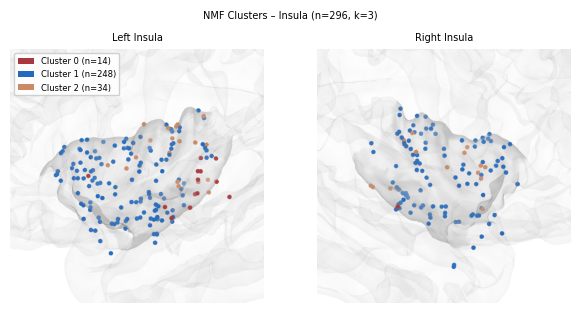

In [25]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# ── 0. Color palette: fixed for n<=6, auto-generated beyond that ──
_fixed_colors = [red, blue, orange, green, '#9B59B6', '#E67E22']
if n_components <= len(_fixed_colors):
    component_palette = _fixed_colors[:n_components]
else:
    cmap = plt.get_cmap('tab10', n_components)
    component_palette = [mcolors.to_hex(cmap(i)) for i in range(n_components)]

cluster_colors = {i: component_palette[i] for i in range(n_components)}

# ── 1. Assign each electrode to the NMF component with the highest weight ──
cluster_labels = (
    W_.groupby('channel')
    .apply(lambda g: g.loc[g['weight'].idxmax(), 'component'])
    .reset_index()
)
cluster_labels.columns = ['channel', 'cluster']

# Merge cluster labels into coordinate table
coords_clustered = coords.merge(cluster_labels, on='channel')

# ── 2. Load insula parcellation labels + pial surfaces ──
insula_patterns = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup'
]

labels_all = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir
)

lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

def get_insula_center(labels, hemi, pial_coords):
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    return pial_coords[verts].mean(axis=0) if verts else pial_coords.mean(axis=0)

lh_center = get_insula_center(labels_all, 'lh', lh_pial_coords)
rh_center = get_insula_center(labels_all, 'rh', rh_pial_coords)

# ── 3. Create Brain objects ──
point_size = 14

for hemi, pial_c, tree, center in [
    ('lh', lh_pial_coords, lh_tree, lh_center),
    ('rh', rh_pial_coords, rh_tree, rh_center),
]:
    brain = Brain(
        "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
        hemi=hemi, background="white", show=False,
        cortex=(0.85, 0.85, 0.85), alpha=0.05, size=(800, 800)
    )

    # highlight insula sulci/gyri
    for lab in labels_all:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            brain.add_label(lab, borders=False, color=(0.75, 0.75, 0.75), alpha=0.5)

    # select electrodes for this hemisphere
    hemi_mask = coords_clustered['x'] < 0 if hemi == 'lh' else coords_clustered['x'] > 0
    hemi_coords = coords_clustered[hemi_mask]

    for cluster_id, color in cluster_colors.items():
        sub = hemi_coords[hemi_coords['cluster'] == cluster_id]
        if sub.empty:
            continue
        xyz = sub[['x', 'y', 'z']].values
        _, idx = tree.query(xyz)
        proj = pial_c[idx]
        cloud = pv.PolyData(proj)
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=point_size, color=color, lighting=False,
        )

    brain.show_view(azimuth=180 if hemi == 'lh' else 0,
                    elevation=90, distance=180, focalpoint=center)

    if hemi == 'lh':
        lh_brain_obj = brain
    else:
        rh_brain_obj = brain

# ── 4. Screenshot + matplotlib composite ──
fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))

axes[0].imshow(lh_brain_obj.screenshot(mode='rgb'))
axes[0].axis('off')
axes[0].set_title('Left Insula', fontsize=fontsize)

axes[1].imshow(rh_brain_obj.screenshot(mode='rgb'))
axes[1].axis('off')
axes[1].set_title('Right Insula', fontsize=fontsize)

legend_elements = [
    Patch(facecolor=cluster_colors[i],
          label=f'Cluster {i} (n={(coords_clustered["cluster"]==i).sum()})')
    for i in range(n_components)
]
axes[0].legend(handles=legend_elements, loc='upper left',
               fontsize=fontsize - 1, framealpha=0.9)

plt.suptitle(
    f'NMF Clusters – Insula (n={len(coords_clustered)}, k={n_components})',
    fontsize=fontsize
)
plt.tight_layout()

lh_brain_obj.close()
rh_brain_obj.close()

# plt.savefig('../img/fig2/nmf_insula_clusters.svg', dpi=300, bbox_inches='tight')
plt.show()